# Project 2 - Exploratory Data Analysis (EDA)
**Intern Project | DecodeLabs | Batch 2026**

### Objective
Analyze the cleaned sales dataset to uncover patterns, trends, and outliers.

### Steps
1. Load & quick overview
2. Basic descriptive statistics
3. Product-wise analysis
4. Order status & payment trends
5. Monthly revenue trend
6. Outlier detection (IQR method)
7. Correlation analysis
8. Key observations & summary

## Step 1 - Import Libraries & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset
df = pd.read_excel('Cleaned_Dataset.xlsx')

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

print('Dataset loaded successfully')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully
Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 2 - Basic Descriptive Statistics

In [3]:
# Overview of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [4]:
# Descriptive stats for numeric columns
df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe().round(2)

,Quantity,UnitPrice,TotalPrice,ItemsInCart
count,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,1053.97,5.48
std,1.41,197.18,819.86,2.28
min,1.00,11.39,11.39,1.00
25%,2.00,186.06,410.52,4.00
50%,3.00,364.21,823.62,5.00
75%,4.00,521.57,1578.48,7.00
max,5.00,699.93,3456.40,10.00


In [5]:
# Mean, Median, Mode for TotalPrice
print('TotalPrice Statistics:')
print(f'  Mean   : {df["TotalPrice"].mean():.2f}')
print(f'  Median : {df["TotalPrice"].median():.2f}')
print(f'  Mode   : {df["TotalPrice"].mode()[0]:.2f}')
print(f'  Std Dev: {df["TotalPrice"].std():.2f}')
print(f'  Min    : {df["TotalPrice"].min():.2f}')
print(f'  Max    : {df["TotalPrice"].max():.2f}')

TotalPrice Statistics:
  Mean   : 1053.97
  Median : 823.62
  Mode   : 211.14
  Std Dev: 819.86
  Min    : 11.39
  Max    : 3456.40


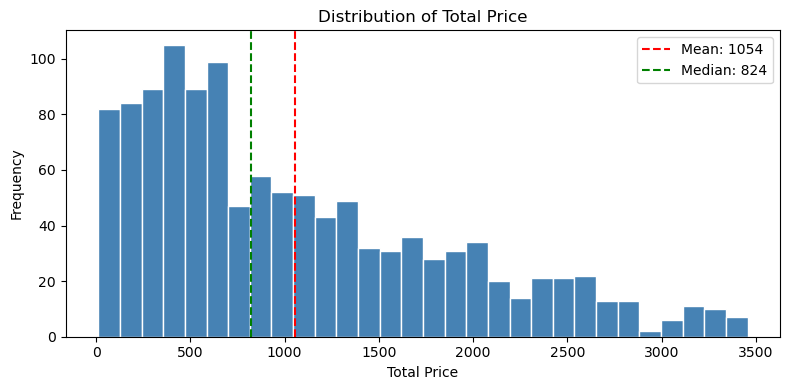

In [6]:
# Distribution of TotalPrice
plt.figure(figsize=(8, 4))
plt.hist(df['TotalPrice'], bins=30, color='steelblue', edgecolor='white')
plt.axvline(df['TotalPrice'].mean(), color='red', linestyle='--', label=f'Mean: {df["TotalPrice"].mean():.0f}')
plt.axvline(df['TotalPrice'].median(), color='green', linestyle='--', label=f'Median: {df["TotalPrice"].median():.0f}')
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

## Step 3 - Product-wise Analysis

In [7]:
# Revenue and order count by product
product_stats = df.groupby('Product')['TotalPrice'].agg(
    Total_Revenue='sum',
    Avg_Order_Value='mean',
    Order_Count='count'
).round(2).sort_values('Total_Revenue', ascending=False)

print('Product-wise Revenue Summary:')
print(product_stats)

Product-wise Revenue Summary:
         Total_Revenue  Avg_Order_Value  Order_Count
Product                                             
Chair        195620.11          1098.99          178
Printer      195612.61          1080.73          181
Laptop       192126.56          1110.56          173
Tablet       186568.95          1042.28          179
Monitor      175651.41          1077.62          163
Desk         167459.93           985.06          170
Phone        151722.39           972.58          156


In [ ]:
# Bar chart - Revenue by Product
product_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(product_rev.index, product_rev.values, color='steelblue', edgecolor='white')
plt.title('Total Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

## Step 4 - Order Status, Payment Method & Referral Source

In [8]:
# Order status distribution
print('Order Status Count:')
print(df['OrderStatus'].value_counts())
print()
print('Payment Method Count:')
print(df['PaymentMethod'].value_counts())
print()
print('Referral Source Count:')
print(df['ReferralSource'].value_counts())

Order Status Count:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Payment Method Count:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

Referral Source Count:
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [ ]:
# Side by side bar charts
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Order Status
os_counts = df['OrderStatus'].value_counts()
axes[0].bar(os_counts.index, os_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Order Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Payment Method
pm_counts = df['PaymentMethod'].value_counts()
axes[1].bar(pm_counts.index, pm_counts.values, color='darkcyan', edgecolor='white')
axes[1].set_title('Payment Method')
axes[1].set_xlabel('Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

# Referral Source
rs_counts = df['ReferralSource'].value_counts()
axes[2].bar(rs_counts.index, rs_counts.values, color='coral', edgecolor='white')
axes[2].set_title('Referral Source')
axes[2].set_xlabel('Source')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Step 5 - Monthly Revenue Trend

In [9]:
# Monthly revenue
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

print('Monthly Revenue:')
print(monthly_revenue.to_string(index=False))

Monthly Revenue:
YearMonth  TotalPrice
  2023-01    56685.75
  2023-02    40117.66
  2023-03    48609.37
  2023-04    27751.71
  2023-05    63836.84
  2023-06    49500.19
  2023-07    42820.66
  2023-08    54352.14
  2023-09    29526.67
  2023-10    52607.85
  2023-11    43079.67
  2023-12    43754.73
  2024-01    38528.08
  2024-02    36909.57
  2024-03    36030.90
  2024-04    49613.14
  2024-05    27909.11
  2024-06    68068.54
  2024-07    42963.98
  2024-08    31991.07
  2024-09    39794.98
  2024-10    37226.97
  2024-11    32413.76
  2024-12    38785.77
  2025-01    29099.40
  2025-02    35317.55
  2025-03    39200.66
  2025-04    31821.20
  2025-05    43396.64
  2025-06    53047.40


In [ ]:
# Line chart - Monthly Revenue Trend
plt.figure(figsize=(12, 4))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['TotalPrice'],
         marker='o', color='steelblue', linewidth=2, markersize=5)
plt.title('Monthly Revenue Trend (2023 - 2025)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 6 - Outlier Detection (IQR Method)

In [10]:
# IQR Method for TotalPrice
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1 (25th percentile) : {Q1:.2f}')
print(f'Q3 (75th percentile) : {Q3:.2f}')
print(f'IQR                  : {IQR:.2f}')
print(f'Lower Bound          : {lower_bound:.2f}')
print(f'Upper Bound          : {upper_bound:.2f}')

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print(f'\nOutliers found: {len(outliers)}')
print(outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']])

Q1 (25th percentile) : 410.52
Q3 (75th percentile) : 1578.47
IQR                  : 1167.95
Lower Bound          : -1341.41
Upper Bound          : 3330.41

Outliers found: 8
        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


In [ ]:
# Boxplot to visualize outliers
plt.figure(figsize=(6, 4))
plt.boxplot(df['TotalPrice'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='steelblue'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Boxplot of Total Price')
plt.ylabel('Total Price')
plt.tight_layout()
plt.show()

## Step 7 - Correlation Analysis

In [11]:
# Correlation matrix
corr = df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].corr().round(3)
print('Correlation Matrix:')
print(corr)

Correlation Matrix:
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity        1.000      0.015       0.615        0.650
UnitPrice       0.015      1.000       0.717        0.001
TotalPrice      0.615      0.717       1.000        0.393
ItemsInCart     0.650      0.001       0.393        1.000


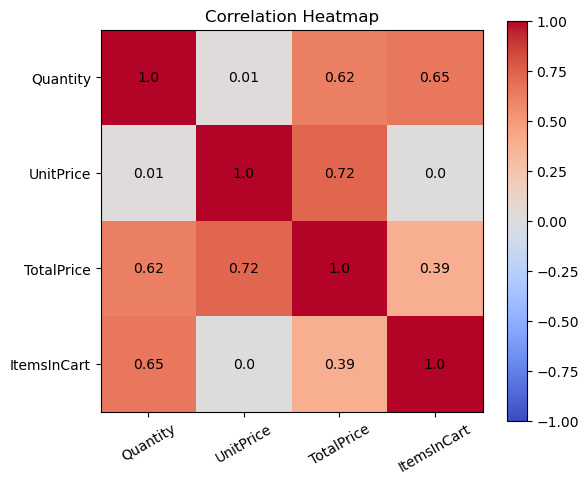

In [12]:
# Heatmap using matplotlib only
fig, ax = plt.subplots(figsize=(6, 5))
cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
corr_data = df[cols].corr().round(2)

im = ax.imshow(corr_data, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=30)
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, str(corr_data.iloc[i, j]), ha='center', va='center', fontsize=10)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

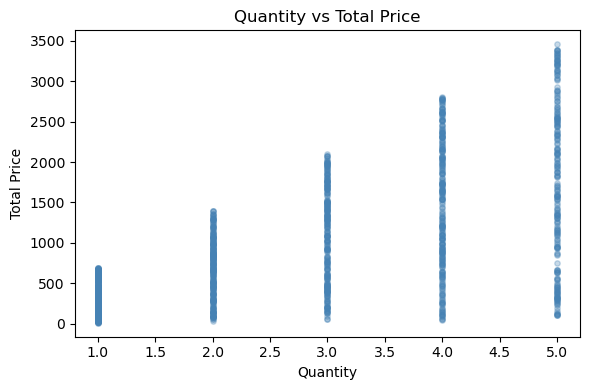

In [13]:
# Scatter plot - Quantity vs TotalPrice
plt.figure(figsize=(6, 4))
plt.scatter(df['Quantity'], df['TotalPrice'], alpha=0.3, color='steelblue', s=15)
plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.tight_layout()
plt.show()

## Step 8 - Key Observations & Summary

In [14]:
print('='*55)
print('         EDA SUMMARY - KEY OBSERVATIONS')
print('='*55)

print('\n1. BASIC STATS')
print(f'   Total Orders    : {len(df)}')
print(f'   Total Revenue   : Rs. {df["TotalPrice"].sum():,.2f}')
print(f'   Avg Order Value : Rs. {df["TotalPrice"].mean():.2f}')
print(f'   Median Order    : Rs. {df["TotalPrice"].median():.2f}')

print('\n2. TOP PERFORMING PRODUCT')
top_prod = df.groupby('Product')['TotalPrice'].sum().idxmax()
top_rev  = df.groupby('Product')['TotalPrice'].sum().max()
print(f'   {top_prod} with Rs. {top_rev:,.2f} total revenue')

print('\n3. ORDER STATUS INSIGHT')
cancelled = df[df['OrderStatus']=='Cancelled'].shape[0]
returned  = df[df['OrderStatus']=='Returned'].shape[0]
print(f'   Cancelled orders : {cancelled} ({cancelled/len(df)*100:.1f}%)')
print(f'   Returned orders  : {returned}  ({returned/len(df)*100:.1f}%)')
print(f'   Combined loss risk: {((cancelled+returned)/len(df)*100):.1f}% of all orders')

print('\n4. TOP REFERRAL SOURCE')
top_ref = df['ReferralSource'].value_counts().idxmax()
top_ref_count = df['ReferralSource'].value_counts().max()
print(f'   {top_ref} brought in the most customers: {top_ref_count} orders')

print('\n5. OUTLIERS')
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.5*IQR)]
print(f'   {len(outliers)} high-value outlier orders detected (above Rs. {Q3 + 1.5*IQR:.2f})')
print(f'   These are likely bulk/premium orders, not errors')

print('\n6. CORRELATION FINDINGS')
print('   UnitPrice & TotalPrice  : strong positive (0.717)')
print('   Quantity & TotalPrice   : moderate positive (0.615)')
print('   ItemsInCart & TotalPrice: weak positive (0.393)')

print('\n7. REVENUE TREND')
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly = df.groupby('YearMonth')['TotalPrice'].sum()
best_month = monthly.idxmax()
print(f'   Best month: {best_month} with Rs. {monthly.max():,.2f}')
print(f'   June 2025 shows highest revenue so far in 2025')

print('\n' + '='*55)

         EDA SUMMARY - KEY OBSERVATIONS

1. BASIC STATS
   Total Orders    : 1200
   Total Revenue   : Rs. 1,264,761.96
   Avg Order Value : Rs. 1053.97
   Median Order    : Rs. 823.62

2. TOP PERFORMING PRODUCT
   Chair with Rs. 195,620.11 total revenue

3. ORDER STATUS INSIGHT
   Cancelled orders : 250 (20.8%)
   Returned orders  : 247  (20.6%)
   Combined loss risk: 41.4% of all orders

4. TOP REFERRAL SOURCE
   Instagram brought in the most customers: 259 orders

5. OUTLIERS
   8 high-value outlier orders detected (above Rs. 3330.41)
   These are likely bulk/premium orders, not errors

6. CORRELATION FINDINGS
   UnitPrice & TotalPrice  : strong positive (0.717)
   Quantity & TotalPrice   : moderate positive (0.615)
   ItemsInCart & TotalPrice: weak positive (0.393)

7. REVENUE TREND
   Best month: 2024-06 with Rs. 68,068.54
   June 2025 shows highest revenue so far in 2025

